# Toy n-gram lang model

In [2]:
# set up the vocab 
V = {'BOS', 'EOS', 'who', 'framed', 'roger', 'rabbit', 'the'}
print(f"Vocabulary size: {len(V)}")
print(V)

Vocabulary size: 7
{'who', 'EOS', 'the', 'framed', 'roger', 'BOS', 'rabbit'}


In [3]:
# introduce the training data 
corpus = [
    "BOS who EOS",
    "BOS who framed roger EOS",
    "BOS roger rabbit EOS",
    "BOS who framed roger rabbit EOS",
    "BOS roger framed who EOS",
    "BOS who framed the rabbit EOS"
]

# Tokenize each sentence into a list of words
tokenized_corpus = [sentence.split() for sentence in corpus]

for sent in tokenized_corpus:
    print(sent)

['BOS', 'who', 'EOS']
['BOS', 'who', 'framed', 'roger', 'EOS']
['BOS', 'roger', 'rabbit', 'EOS']
['BOS', 'who', 'framed', 'roger', 'rabbit', 'EOS']
['BOS', 'roger', 'framed', 'who', 'EOS']
['BOS', 'who', 'framed', 'the', 'rabbit', 'EOS']


In [4]:
# what are the unigram probabilities (I can use this to get P('rabbit'))
from collections import Counter

# Count occurrences of every word across all sentences
unigram_counts = Counter()
for sent in tokenized_corpus:
    unigram_counts.update(sent)

total_word_count = sum(unigram_counts.values())

unigram_probs = {word: count / total_word_count 
                  for word, count in unigram_counts.items()}

print("Unigram counts:")
for word, count in unigram_counts.items():
    print(f"  {word}: {count}")

print(f"\nTotal word count: {total_word_count}")

print("\nUnigram probabilities P(word):")
for word, prob in sorted(unigram_probs.items(), key=lambda x: -x[1]):
    print(f"  P({word}) = {prob:.4f}")

Unigram counts:
  BOS: 6
  who: 5
  EOS: 6
  framed: 4
  roger: 4
  rabbit: 3
  the: 1

Total word count: 29

Unigram probabilities P(word):
  P(BOS) = 0.2069
  P(EOS) = 0.2069
  P(who) = 0.1724
  P(framed) = 0.1379
  P(roger) = 0.1379
  P(rabbit) = 0.1034
  P(the) = 0.0345


In [5]:
# compute bigram probabilities (I can use this to calc P('rabbit'|'roger'))
# Count bigrams (consecutive word pairs) and the count of each "context" word
bigram_counts = Counter()
context_counts = Counter()

for sent in tokenized_corpus:
    for i in range(len(sent) - 1):
        w1, w2 = sent[i], sent[i + 1]
        bigram_counts[(w1, w2)] += 1
        context_counts[w1] += 1

# P(w2 | w1) = count(w1, w2) / count(w1)
bigram_probs = {bigram: count / context_counts[bigram[0]] 
                 for bigram, count in bigram_counts.items()}

print("Bigram counts:")
for bigram, count in bigram_counts.items():
    print(f"  {bigram}: {count}")

print("\nBigram probabilities P(w2 | w1):")
for (w1, w2), prob in sorted(bigram_probs.items(), key=lambda x: (x[0][0], -x[1])):
    print(f"  P({w2} | {w1}) = {prob:.4f}")

Bigram counts:
  ('BOS', 'who'): 4
  ('who', 'EOS'): 2
  ('who', 'framed'): 3
  ('framed', 'roger'): 2
  ('roger', 'EOS'): 1
  ('BOS', 'roger'): 2
  ('roger', 'rabbit'): 2
  ('rabbit', 'EOS'): 3
  ('roger', 'framed'): 1
  ('framed', 'who'): 1
  ('framed', 'the'): 1
  ('the', 'rabbit'): 1

Bigram probabilities P(w2 | w1):
  P(who | BOS) = 0.6667
  P(roger | BOS) = 0.3333
  P(roger | framed) = 0.5000
  P(who | framed) = 0.2500
  P(the | framed) = 0.2500
  P(EOS | rabbit) = 1.0000
  P(rabbit | roger) = 0.5000
  P(EOS | roger) = 0.2500
  P(framed | roger) = 0.2500
  P(rabbit | the) = 1.0000
  P(framed | who) = 0.6000
  P(EOS | who) = 0.4000


In [9]:
sum([len(c) for c in tokenized_corpus])

29

# Programming assignment

In [1]:
# trying out the sentence_split_and_tokenize_demo
from ngram_lm import sentence_split_and_tokenize_demo

/Users/rajivkhandpur/anaconda3/envs/ssm_hw2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sentence_splitter import SentenceSplitter
from transformers import AutoTokenizer

In [4]:
splitter = SentenceSplitter(language='en')
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

/Users/rajivkhandpur/anaconda3/envs/ssm_hw2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
sample_paragraph = (
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. "
    "It is named after the engineer Gustave Eiffel, whose company designed and built the tower. "
    "Locally nicknamed 'La dame de fer', it was constructed from 1887 to 1889."
)

sample_data = {'text': [""] * 10 + [sample_paragraph]}

In [18]:
sample_data

{'text': ['',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France. It is named after the engineer Gustave Eiffel, whose company designed and built the tower. Locally nicknamed 'La dame de fer', it was constructed from 1887 to 1889."]}

In [20]:
sentence_split_and_tokenize_demo(sample_data, splitter, tokenizer)

---------- split into sentences ----------
['The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.', 'It is named after the engineer Gustave Eiffel, whose company designed and built the tower.', "Locally nicknamed 'La dame de fer', it was constructed from 1887 to 1889."]
 -> The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
 -> It is named after the engineer Gustave Eiffel, whose company designed and built the tower.
 -> Locally nicknamed 'La dame de fer', it was constructed from 1887 to 1889.
---------- tokenize the first sentence ----------
Tokens: ['The', 'E', '##iff', '##el', 'Tower', 'is', 'a', 'wrought', '-', 'iron', 'lattice', 'tower', 'on', 'the', 'Cha', '##mp', 'de', 'Mars', 'in', 'Paris', ',', 'France', '.']
Tokens to indices: [1109, 142, 11093, 1883, 5646, 1110, 170, 20533, 118, 3926, 19843, 3590, 1113, 1103, 24705, 8223, 1260, 7403, 1107, 2123, 117, 1699, 119]


/Users/rajivkhandpur/anaconda3/envs/ssm_hw2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---------- Load Dataset ----------
---------- an example from the train set ----------
 The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ person . A character can only act once per @-@ turn , but characters can be granted multiple turns at the expense of other characters ' turns . Each character has a field and distance of movement limited by their Action Gauge . Up to nine characters can be assigned to a single mission . During gameplay , characters will call out if something happens to them , such as their health points ( HP ) getting low or being knocked out by enemy attacks . Each character has specific " Potentials " , skills unique to each character . They are divided into " Personal Potential " , which are innate skills that remain una

/Users/rajivkhandpur/anaconda3/envs/ssm_hw2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


["The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles .", 'During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ person .', "A character can only act once per @-@ turn , but characters can be granted multiple turns at the expense of other characters ' turns .", 'Each character has a field and distance of movement limited by their Action Gauge .', 'Up to nine characters can be assigned to a single mission .', 'During gameplay , characters will call out if something happens to them , such as their health points ( HP ) getting low or being knocked out by enemy attacks .', 'Each character has specific " Potentials " , skills unique to each character .', 'They are divided into " Personal Potential " , which are innate skills that remain unaltered unless otherwise dictated by the story and can either help

100%|██████████| 100000/100000 [00:42<00:00, 2337.10it/s]


---------- plot the top 10 next word probabilities after ('move', 'to') ----------
---------- plot the top 10 next word probabilities after ('the', 'news') ----------
---------- generated text 1 ----------
According to the report, the first time in the United States, and the other hand, the first time in the United States, and the other hand, the first time
---------- generated text 2 ----------
The president of the association ' s " The One I Love You ' re not here to Connacht side of the game ' s " The One I Love You ' re not


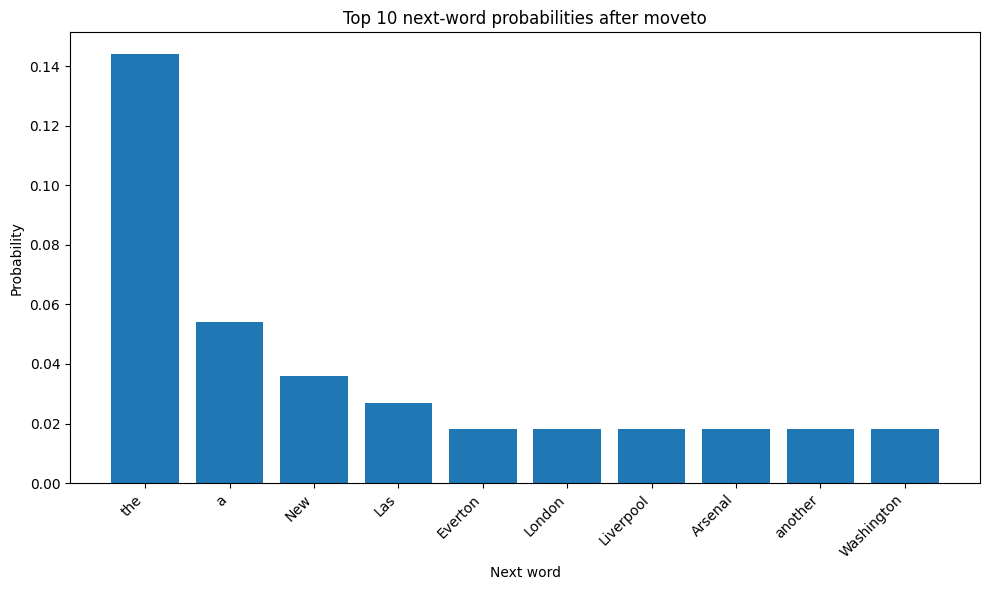

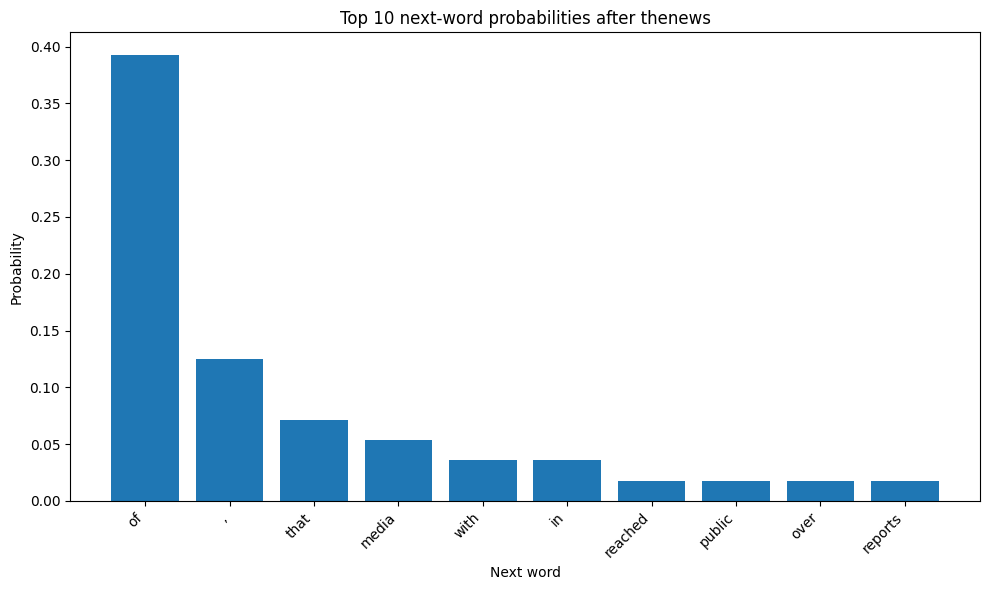

In [1]:
from ngram_lm import run_ngram
run_ngram()